[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Data-Crew/transport-networks-lab/blob/main/Notebooks/Practica_guiada1_IntroNx.ipynb)

# Práctica guiada 1 — Introducción a grafos con `NetworkX`

<img width="700" src="https://github.com/PyMap/AUPY/blob/master/imagenes/nodos_ejes.png?raw=1">

Una **red** es un sistema de relaciones; un **grafo** es su representación
matemática. No hay una única forma de traducir una a la otra: modelar es
decidir qué se representa y qué se deja afuera.

En redes de transporte la convención habitual es: las estaciones son **nodos**,
y las calles o viajes que las unen son **ejes**.

Vamos a construir a mano un recorte de la red de subtes de CABA —las líneas B,
C y D alrededor del Obelisco— y usarlo para recorrer los conceptos básicos:
atributos, tipos de grafo, y las métricas que describen una red.

Documentación: [NetworkX](https://networkx.org/documentation/stable/reference/introduction.html).

## Setup

In [1]:
import random

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from matplotlib import cm

# Semilla fija: sin esto los pesos aleatorios cambian en cada corrida
# y los números que comenta el texto dejan de coincidir.
random.seed(42)

plt.style.use("ggplot")

In [2]:
from google.colab import drive

drive.mount("/drive/")

DATA_DIR = "/drive/MyDrive/transport-networks-lab/Data"

Mounted at /drive/


## Sección 1. Armar el grafo

### 1.1. Nodos y ejes

Un grafo se construye en dos pasos: primero los nodos, después las conexiones.
Nuestra topología son tres líneas de tres estaciones cada una, más dos ejes de
combinación que las unen.

In [3]:
G = nx.Graph()
G.add_nodes_from(range(9))

# Cada línea es una cadena de tres estaciones consecutivas
for n in range(0, 9, 3):
    G.add_edge(n, n + 1)
    G.add_edge(n + 1, n + 2)

# Y estas dos son las combinaciones entre líneas (el nudo del Obelisco)
G.add_edge(2, 5)
G.add_edge(7, 5)

G.name = "Subtes CABA"
print(f"{G.number_of_nodes()} nodos, {G.number_of_edges()} ejes")
print(f"Ejes: {list(G.edges())}")

9 nodos, 8 ejes
Ejes: [(0, 1), (1, 2), (2, 5), (3, 4), (4, 5), (5, 7), (6, 7), (7, 8)]


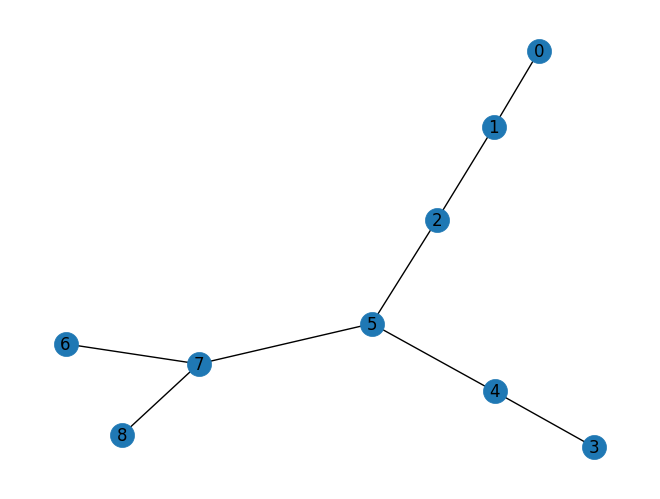

In [4]:
# Sin posiciones, draw las inventa: el dibujo cambia en cada ejecución
nx.draw(G, with_labels=True)

El grafo ya existe, pero el dibujo es arbitrario: `draw` acomoda los nodos con
un algoritmo de layout porque todavía **no le dimos ninguna noción de espacio**.
Eso lo resolvemos con atributos.

### 1.2. Atributos de nodos

Los nodos se comportan como diccionarios: podemos colgarles cualquier
información. Acá les vamos a poner nombre de estación, línea, color y
coordenadas.

In [5]:
# (nodo, nombre en el CSV, línea, etiqueta para el gráfico)
# El orden de esta lista ES el número de nodo. Explicitarlo evita depender
# del orden en que venga el CSV.
ESTACIONES = [
    (0, "CALLAO - MAESTRO ALFREDO BRAVO", "B", "CALLAO (B)"),   # línea B
    (1, "URUGUAY", "B", "URUGUAY"),
    (2, "C. PELLEGRINI", "B", "C. PELLEGRINI"),
    (3, "CALLAO", "D", "CALLAO (D)"),                           # línea D
    (4, "TRIBUNALES - TEATRO COLÓN", "D", "TRIBUNALES"),
    (5, "9 DE JULIO", "D", "9 DE JULIO"),
    (6, "LAVALLE", "C", "LAVALLE"),                             # línea C
    (7, "DIAGONAL NORTE", "C", "DIAGONAL NORTE"),
    (8, "AV. DE MAYO", "C", "AV. DE MAYO"),
]

COLOR_LINEA = {"B": "red", "C": "blue", "D": "green"}

In [6]:
subte = pd.read_csv(f"{DATA_DIR}/estaciones-de-subte.csv")

# CALLAO existe en B y en D, así que la clave es el par (nombre, línea).
# Ojo: en la línea B el nombre completo es "CALLAO - MAESTRO ALFREDO BRAVO".
coords = {(r.estacion, r.linea): (r.long, r.lat) for r in subte.itertuples()}

# Chequeamos las nueve de una vez: si algún nombre no coincide queremos
# verlas todas juntas y no ir descubriéndolas de a una.
faltantes = [(e, l) for _, e, l, _ in ESTACIONES if (e, l) not in coords]
if faltantes:
    raise KeyError(f"No están en el CSV: {faltantes}")

for nodo, estacion, linea, etiqueta in ESTACIONES:
    G.nodes[nodo]["estacion"] = etiqueta        # nombre corto, para dibujar
    G.nodes[nodo]["nombre_csv"] = estacion      # nombre completo, por trazabilidad
    G.nodes[nodo]["linea"] = linea
    G.nodes[nodo]["color"] = COLOR_LINEA[linea]
    G.nodes[nodo]["coord"] = coords[(estacion, linea)]

list(G.nodes(data=True))[:2]

[(0,
  {'estacion': 'CALLAO (B)',
   'nombre_csv': 'CALLAO - MAESTRO ALFREDO BRAVO',
   'linea': 'B',
   'color': 'red',
   'coord': (-58.3923142350887, -34.6044195428608)}),
 (1,
  {'estacion': 'URUGUAY',
   'nombre_csv': 'URUGUAY',
   'linea': 'B',
   'color': 'red',
   'coord': (-58.3872961335408, -34.6040935531057)})]

In [7]:
# Los atributos permiten filtrar. Las comprehension lists son el recurso
# idiomático para recorrer nodos con su metadata.
[n for n, d in G.nodes(data=True) if d["linea"] == "B"]

[0, 1, 2]

### 1.3. Atributos de ejes

A los ejes se accede por el par de nodos que conectan. El atributo más
importante en redes de transporte es el **peso** (`weight`): la intensidad de
la conexión. Puede ser cantidad de pasajeros, tiempo de viaje, distancia — lo
que la pregunta requiera.

In [8]:
COMBINACIONES = [(2, 5), (5, 7)]

for u, v in G.edges():
    es_combinacion = (u, v) in COMBINACIONES or (v, u) in COMBINACIONES
    G.edges[u, v]["fecha"] = "2019-10-01"
    G.edges[u, v]["hora"] = "09:30:00"
    # Las combinaciones mueven más gente que los tramos internos de una línea
    G.edges[u, v]["pasajeros"] = (
        random.randint(100, 200) if es_combinacion else random.randint(10, 100)
    )

G.edges[0, 1]

{'fecha': '2019-10-01', 'hora': '09:30:00', 'pasajeros': 91}

In [9]:
# Filtramos ejes igual que los nodos, pero iterando sobre (u, v, data)
[(u, v) for u, v, d in G.edges(data=True) if d["pasajeros"] > 75]

[(0, 1), (2, 5), (5, 7)]

### 1.4. Visualizar

Ahora que los nodos tienen coordenadas, `pos` fija el dibujo y el grafo empieza
a parecerse al mapa real.

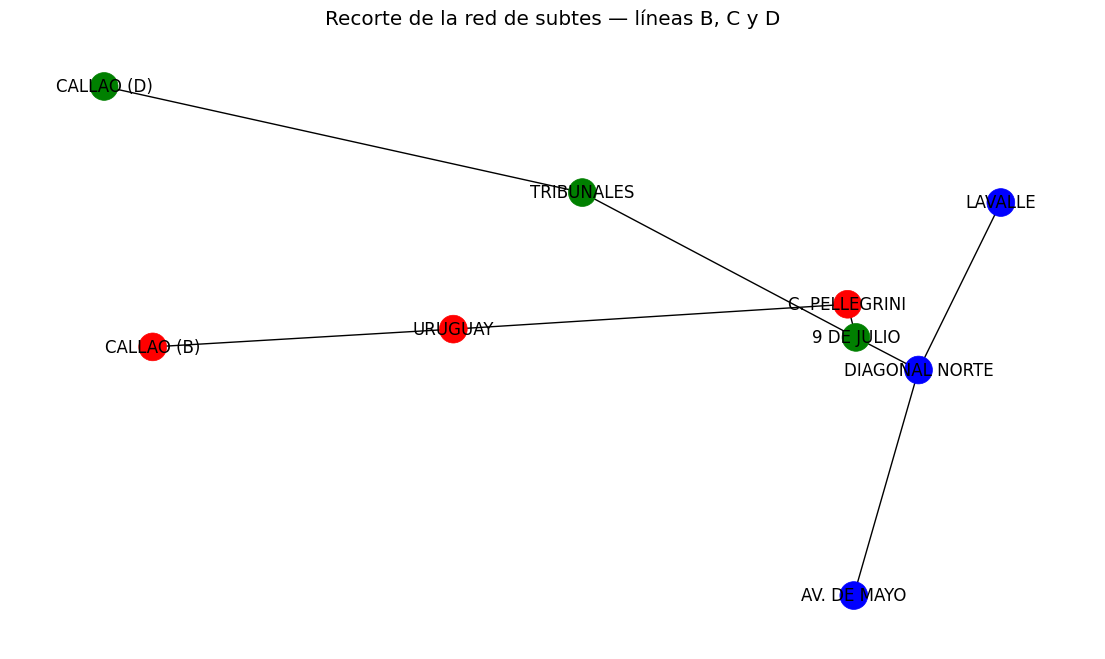

In [10]:
pos = nx.get_node_attributes(G, "coord")
etiquetas = nx.get_node_attributes(G, "estacion")
colores = [G.nodes[n]["color"] for n in G.nodes()]

fig, ax = plt.subplots(figsize=(14, 8))
nx.draw(G, pos, labels=etiquetas, with_labels=True,
        node_size=400, node_color=colores, ax=ax)
ax.set_title("Recorte de la red de subtes — líneas B, C y D")
plt.show()

Las listas de colores y anchos se pasan **en el mismo orden** que devuelven
`G.nodes()` y `G.edges()`. Usemos eso para que el ancho de cada eje refleje su
cantidad de pasajeros.

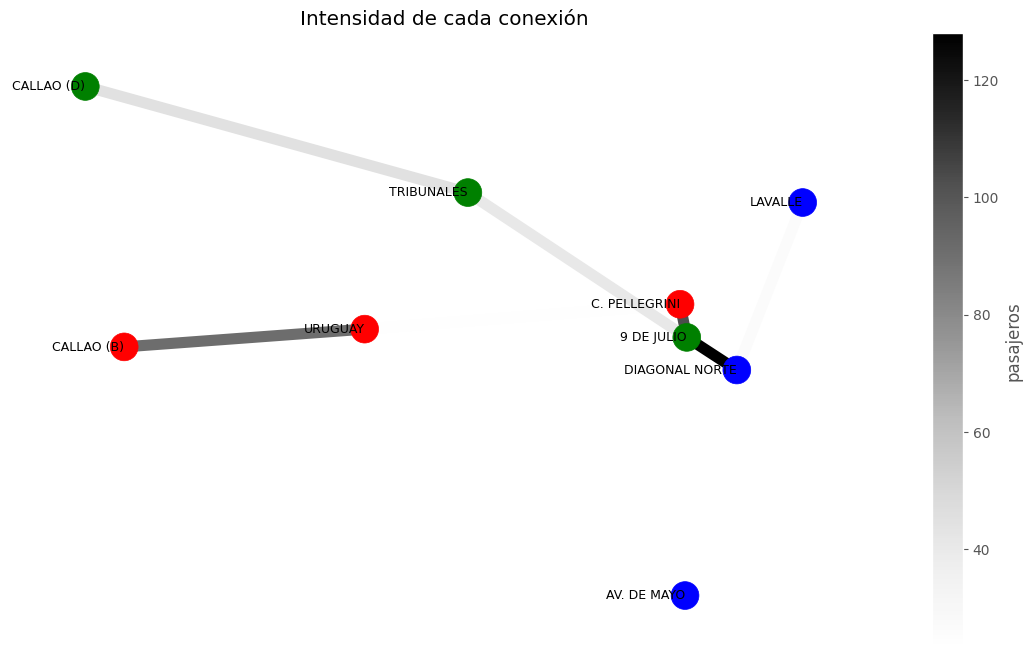

In [11]:
fig, ax = plt.subplots(figsize=(14, 8))

pesos = [G[u][v]["pasajeros"] for u, v in G.edges()]

ejes = nx.draw_networkx_edges(G, pos, width=8, edge_color=pesos,
                              edge_cmap=cm.Greys, ax=ax)
nx.draw_networkx_nodes(G, pos, node_size=400, node_color=colores, ax=ax)
nx.draw_networkx_labels(G, pos, labels=etiquetas, font_size=9,
                        horizontalalignment="right", ax=ax)

plt.colorbar(ejes, ax=ax, label="pasajeros")
ax.set_axis_off()
ax.set_title("Intensidad de cada conexión")
plt.show()

## Sección 2. Tipos de grafo

Nuestro `G` es un `Graph`: no distingue el sentido del viaje ni admite dos ejes
entre el mismo par de nodos. Esas dos propiedades definen las cuatro clases
de NetworkX:

| Clase | ¿Distingue A→B de B→A? | ¿Admite ejes repetidos? |
|---|---|---|
| `Graph` | No | No |
| `DiGraph` | Sí | No |
| `MultiGraph` | No | Sí |
| `MultiDiGraph` | Sí | Sí |

En vez de recorrerlas una por una, las poblamos con **las mismas cuatro
conexiones** y comparamos qué cuenta cada una.

In [12]:
# Mismos datos para las cuatro: dos veces 0->1, una 1->0, y un selfloop en 1
CONEXIONES = [(0, 1), (0, 1), (1, 0), (1, 1)]

resumen = []
for nombre, clase in [("Graph", nx.Graph), ("DiGraph", nx.DiGraph),
                      ("MultiGraph", nx.MultiGraph), ("MultiDiGraph", nx.MultiDiGraph)]:
    g = clase(CONEXIONES)
    resumen.append({
        "clase": nombre,
        "ejes totales": g.number_of_edges(),
        "0→1": g.number_of_edges(0, 1),
        "1→0": g.number_of_edges(1, 0),
        "selfloops": nx.number_of_selfloops(g),
    })

pd.DataFrame(resumen).set_index("clase")

,ejes totales,0→1,1→0,selfloops
clase,,,,
Graph,2,1,1,1
DiGraph,3,1,1,1
MultiGraph,4,3,3,1
MultiDiGraph,4,2,1,1


Cuatro conexiones idénticas, cuatro respuestas distintas:

- `Graph` las colapsa todas en **un solo eje** más el selfloop.
- `DiGraph` separa `0→1` de `1→0`, pero guarda una sola copia de cada uno.
- `MultiGraph` conserva las repeticiones pero `0→1` y `1→0` son lo mismo.
- `MultiDiGraph` conserva las cuatro.

> **Sobre el dibujo:** `draw` traza los ejes paralelos superpuestos, así que un
> multigrafo se ve igual que un grafo simple. No es un error del código:
> NetworkX prioriza el *análisis* sobre la visualización. Para dibujar
> multigrafos con ejes separados existen [graphviz](https://www.graphviz.org/gallery/)
> y [nxviz](https://github.com/ericmjl/nxviz).

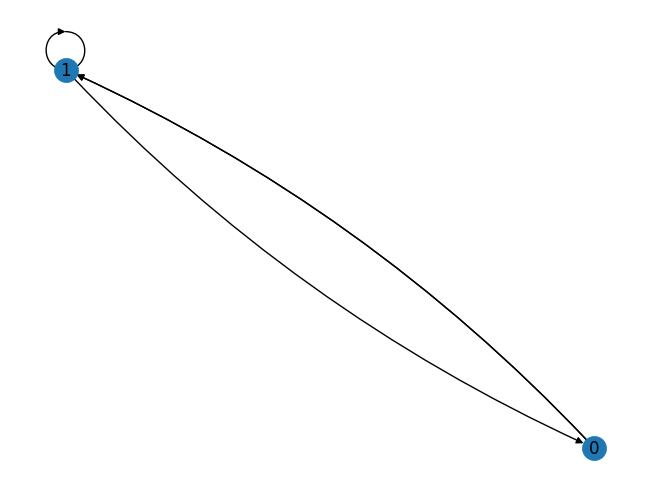

In [13]:
# Los grafos dirigidos se dibujan con flechas; el `rad` las curva para que
# ida y vuelta no queden una encima de la otra.
MD = nx.MultiDiGraph(CONEXIONES)
nx.draw(MD, with_labels=True, arrows=True, connectionstyle="arc3, rad=0.1")

### 2.1. Matriz de adyacencia

Otra forma de escribir el mismo grafo: una matriz donde la celda `(i, j)` vale
1 si los nodos están conectados y 0 si no. Si en vez de 1 ponemos el peso,
la matriz describe también la intensidad.

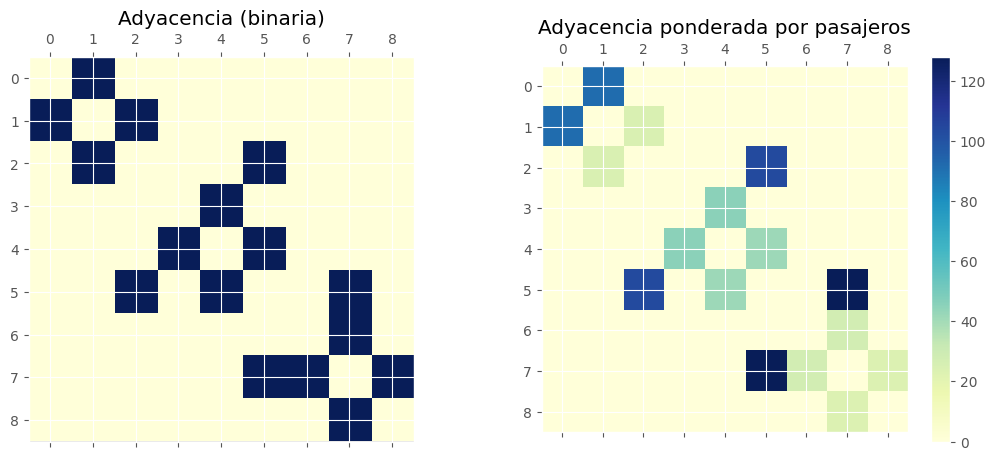

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].matshow(nx.to_numpy_array(G), cmap="YlGnBu")
axes[0].set_title("Adyacencia (binaria)")

pond = axes[1].matshow(nx.to_numpy_array(G, weight="pasajeros"), cmap="YlGnBu")
axes[1].set_title("Adyacencia ponderada por pasajeros")
plt.colorbar(pond, ax=axes[1])

for ax in axes:
    ax.set_xticks(range(9))
    ax.set_yticks(range(9))
plt.show()

Fijate que la matriz es **simétrica**: es la firma visual de un grafo no
dirigido. En un `DiGraph` dejaría de serlo.

## Sección 3. Métricas

### 3.1. Grado de un nodo

El **grado** es la cantidad de ejes que tocan a un nodo. En un grafo dirigido
se descompone en *in-degree* (entrantes) y *out-degree* (salientes).

<img width="900" src="https://github.com/PyMap/AUPY/blob/master/imagenes/distribucion_grados.png?raw=1">

In [15]:
grados = pd.Series(dict(G.degree()), name="grado").to_frame()
grados["estacion"] = [G.nodes[n]["estacion"] for n in grados.index]
grados["linea"] = [G.nodes[n]["linea"] for n in grados.index]
grados.sort_values("grado", ascending=False)

,grado,estacion,linea
7,3,DIAGONAL NORTE,C
5,3,9 DE JULIO,D
4,2,TRIBUNALES,D
1,2,URUGUAY,B
2,2,C. PELLEGRINI,B
0,1,CALLAO (B),B
3,1,CALLAO (D),D
6,1,LAVALLE,C
8,1,AV. DE MAYO,C


Los nodos 5 y 7 tienen grado 3: son las estaciones de combinación. Los de grado
1 son las cabeceras de cada línea. La topología se lee en los números.

### 3.2. Grado promedio de la red

Pasamos del nodo a la red entera: en promedio, ¿con cuántos vecinos conecta
cada nodo?

<img width="900" src="https://github.com/PyMap/AUPY/blob/master/imagenes/grado_promedio_red.png?raw=1">

En un grafo **no dirigido** cada eje aporta grado a sus dos extremos, así que
la suma de grados es `2·E` y el promedio es `2·E / N`. En uno **dirigido** cada
eje aporta un solo grado (una salida o una entrada), y el promedio es `E / N`.

In [16]:
GD = G.to_directed()

print(f"No dirigido: 2*{G.number_of_edges()}/{G.number_of_nodes()} = "
      f"{2 * G.number_of_edges() / G.number_of_nodes():.2f}")
print(f"Dirigido:      {GD.number_of_edges()}/{GD.number_of_nodes()} = "
      f"{GD.number_of_edges() / GD.number_of_nodes():.2f}")

# Verificación: el promedio de los grados individuales tiene que dar lo mismo
print(f"\nPromedio empírico: {np.mean([d for _, d in G.degree()]):.2f}")

No dirigido: 2*8/9 = 1.78
Dirigido:      16/9 = 1.78

Promedio empírico: 1.78


El grado promedio es **1,78**, no 2. Es un promedio: no hay por qué redondearlo,
y hacerlo esconde información. Que dé menos de 2 nos dice que la red está
*poco* conectada — muchas estaciones son cabeceras con un solo vecino.

### 3.3. Degree centrality

El grado en bruto no es comparable entre redes de distinto tamaño. La
**centralidad de grado** lo normaliza: es el grado dividido por la cantidad de
conexiones *posibles*, es decir `N − 1`. El resultado va de 0 a 1.

In [17]:
n2 = G.degree[2]
print(f"Grado del nodo 2: {n2}")
print(f"Centralidad = {n2}/(9-1) = {n2 / (G.number_of_nodes() - 1)}")
print(f"nx.degree_centrality: {nx.degree_centrality(G)[2]}")

Grado del nodo 2: 2
Centralidad = 2/(9-1) = 0.25
nx.degree_centrality: 0.25


> **Cuidado con una coincidencia.** En este grafo `N − 1 = 8` y la cantidad de
> ejes también es 8, así que dividir por los ejes da el mismo número. Es
> casualidad, no una fórmula alternativa: el denominador correcto es siempre
> `N − 1`. La celda siguiente lo muestra agregando un eje.

In [18]:
H = G.copy()
H.add_edge(0, 3)   # ahora N-1 = 8 pero los ejes son 9

print(f"correcto  grado/(N-1) : {H.degree[2] / (H.number_of_nodes() - 1):.4f}")
print(f"incorrecto grado/ejes : {H.degree[2] / H.number_of_edges():.4f}")
print(f"nx.degree_centrality  : {nx.degree_centrality(H)[2]:.4f}")

correcto  grado/(N-1) : 0.2500
incorrecto grado/ejes : 0.2222
nx.degree_centrality  : 0.2500


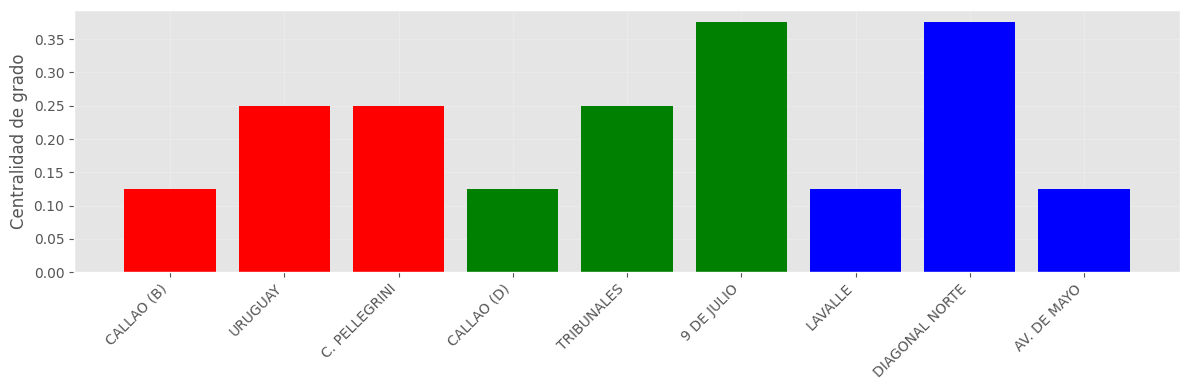

In [19]:
centralidad = nx.degree_centrality(G)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar([G.nodes[n]["estacion"] for n in centralidad],
       list(centralidad.values()),
       color=[G.nodes[n]["color"] for n in centralidad])
ax.set_ylabel("Centralidad de grado")
ax.grid(True, alpha=0.2)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 3.4. Caminos y distancias

La **distancia** entre dos nodos es la cantidad mínima de ejes que hay que
recorrer para ir de uno al otro. NetworkX lo resuelve directamente.

In [20]:
print(f"¿Hay camino de 0 a 3? {nx.has_path(G, 0, 3)}")
print(f"Camino más corto:      {nx.shortest_path(G, 0, 3)}")
print(f"Largo:                 {nx.shortest_path_length(G, 0, 3)} tramos")

# Traducido a nombres de estación
ruta = nx.shortest_path(G, 0, 3)
print("\n" + " → ".join(G.nodes[n]["estacion"] for n in ruta))

¿Hay camino de 0 a 3? True
Camino más corto:      [0, 1, 2, 5, 4, 3]
Largo:                 5 tramos

CALLAO (B) → URUGUAY → C. PELLEGRINI → 9 DE JULIO → TRIBUNALES → CALLAO (D)


Callao (B) y Callao (D) están a **5 tramos**, aunque en la superficie sean casi
la misma esquina: para ir de una a otra hay que bajar hasta el Obelisco y
volver. Es exactamente el tipo de cosa que un grafo hace visible y un mapa no.

`shortest_path` es adyacencia encadenada: la conexión directa es un caso
particular de camino de largo 1, no un concepto aparte.

In [21]:
# Para toda la red de una sola vez
largos = dict(nx.all_pairs_shortest_path_length(G))

pd.DataFrame(largos).sort_index().sort_index(axis=1)

,0,1,2,3,4,5,6,7,8
0,0,1,2,5,4,3,5,4,5
1,1,0,1,4,3,2,4,3,4
2,2,1,0,3,2,1,3,2,3
3,5,4,3,0,1,2,4,3,4
4,4,3,2,1,0,1,3,2,3
5,3,2,1,2,1,0,2,1,2
6,5,4,3,4,3,2,0,1,2
7,4,3,2,3,2,1,1,0,1
8,5,4,3,4,3,2,2,1,0


#### Caminos ponderados

En transporte el camino más corto suele calcularse sobre **tiempo de viaje**,
no cantidad de tramos. Se pasa el atributo con `weight`.

In [22]:
for u, v in G.edges():
    es_combinacion = (u, v) in COMBINACIONES or (v, u) in COMBINACIONES
    # Combinar cuesta caro: hay que caminar entre andenes
    G.edges[u, v]["tiempo_viaje"] = random.randint(5, 15) if es_combinacion else random.randint(1, 4)

print("Sin peso: ", nx.shortest_path(G, 0, 3))
print("Con peso: ", nx.shortest_path(G, 0, 3, weight="tiempo_viaje"))
print(f"\n¿Es un árbol? {nx.is_tree(G)}")

Sin peso:  [0, 1, 2, 5, 4, 3]
Con peso:  [0, 1, 2, 5, 4, 3]

¿Es un árbol? True


Los dos caminos son idénticos, y el motivo es estructural: **este grafo es un
árbol** (9 nodos, 8 ejes, conexo). En un árbol existe exactamente *un* camino
entre cada par de nodos, así que los pesos pueden cambiar el **costo** del
recorrido pero nunca la **ruta** — no hay alternativa entre la cual elegir.

Los pesos recién importan cuando hay ciclos. La red de subtes real los tiene;
este recorte no.

### 3.5. Betweenness centrality

La centralidad de grado mide cuántos vecinos tiene un nodo. La **centralidad de
intermediación** mide algo distinto: qué proporción de los caminos más cortos
de toda la red pasan *a través* de él. Es una medida de nodo-puente.

In [23]:
intermediacion = nx.betweenness_centrality(G)

resultado = pd.DataFrame({
    "estacion": [G.nodes[n]["estacion"] for n in G.nodes()],
    "linea": [G.nodes[n]["linea"] for n in G.nodes()],
    "grado": [G.degree[n] for n in G.nodes()],
    "betweenness": [round(intermediacion[n], 3) for n in G.nodes()],
}).sort_values("betweenness", ascending=False)

resultado

,estacion,linea,grado,betweenness
5,9 DE JULIO,D,3,0.750
7,DIAGONAL NORTE,C,3,0.464
2,C. PELLEGRINI,B,2,0.429
4,TRIBUNALES,D,2,0.250
1,URUGUAY,B,2,0.250
0,CALLAO (B),B,1,0.000
3,CALLAO (D),D,1,0.000
6,LAVALLE,C,1,0.000
8,AV. DE MAYO,C,1,0.000


`9 DE JULIO` encabeza con **0,75**: tres de cada cuatro caminos más cortos de la
red pasan por esa estación. Tiene sentido, es la combinación central.

El dato interesante está en comparar las dos columnas. `9 DE JULIO` y
`DIAGONAL NORTE` tienen **el mismo grado (3)**, pero betweenness muy distinto
(0,75 contra 0,46). El grado cuenta vecinos; la intermediación mide posición
estructural. Un nodo puede tener pocos vecinos y ser crítico igual, si es el
único paso entre dos partes de la red.

Operativamente: si `9 DE JULIO` cierra, la red no pierde una estación, se parte
en pedazos incomunicados.

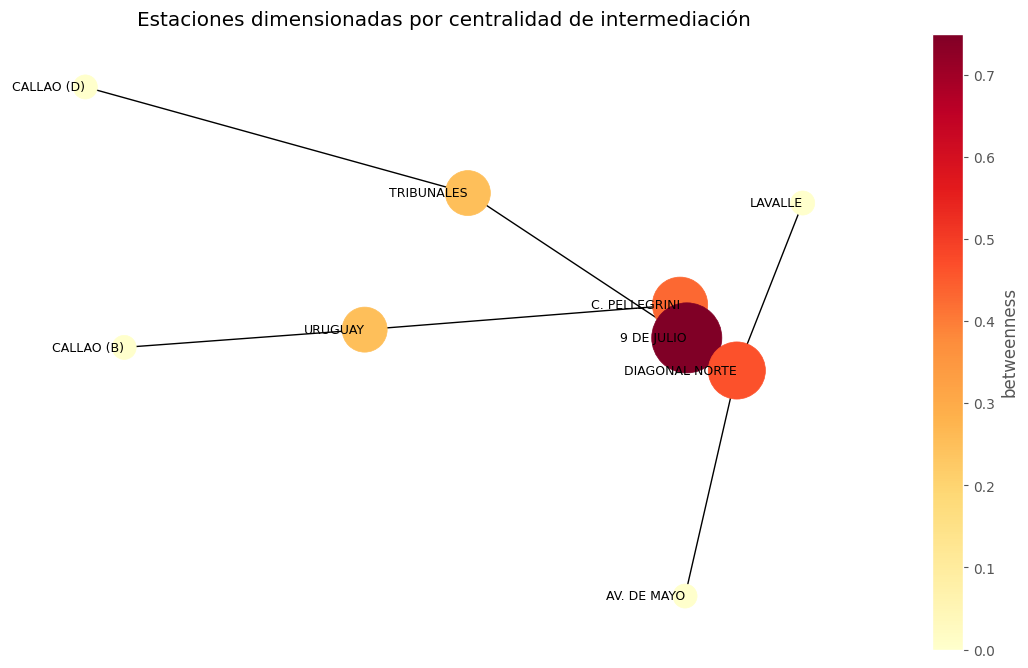

In [24]:
fig, ax = plt.subplots(figsize=(14, 8))

nx.draw_networkx_edges(G, pos, ax=ax)
nodos = nx.draw_networkx_nodes(
    G, pos,
    node_size=[300 + 3000 * intermediacion[n] for n in G.nodes()],
    node_color=[intermediacion[n] for n in G.nodes()],
    cmap=cm.YlOrRd, ax=ax,
)
nx.draw_networkx_labels(G, pos, labels=etiquetas, font_size=9,
                        horizontalalignment="right", ax=ax)

plt.colorbar(nodos, ax=ax, label="betweenness")
ax.set_axis_off()
ax.set_title("Estaciones dimensionadas por centralidad de intermediación")
plt.show()

## Para cerrar

1. **Los atributos son lo que hace útil a un grafo.** Sin coordenadas es un
   dibujo arbitrario; sin pesos, todas las conexiones valen igual.
2. **La clase de grafo es una decisión de modelado.** Las mismas cuatro
   conexiones dan cuatro grafos distintos.
3. **Grado y betweenness responden preguntas diferentes.** Cuántos vecinos
   tiene un nodo, versus qué pasa con la red si ese nodo desaparece.